#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [1]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [3]:
# Import Eda Libraries
os.chdir(scripts_path)
from exploration import coeff_var_skew, num_uni_hist_box
from ml_eda import lr_features_evaluation, confusion_matrix_display, classification_report_display, roc_curve_display

In [4]:
# Import Advanced Libraries
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Input
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, classification_report, roc_curve, auc

2025-03-03 12:52:38.129992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
# Load & Copy Dataset
os.chdir(data_exploration_path)
original_df = pd.read_csv("eda_processed_data.csv")
df = original_df.copy()

In [6]:
# First Column Drop
df.drop(columns='Unnamed: 0',inplace=True)

In [7]:
# Dataset Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,IsWeekend,Regions,Topic Group
287,8.287,37,67938.77,85.344,0,0,1,6,0,Oceania,2
548,7.953,33,61467.33,94.688,0,0,6,2,1,Asia,2
235,4.042,45,40183.75,53.560,1,1,2,3,0,Europe,2


#### B. FEATURE ENGINEERING

In [8]:
# Missing Value Check
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
Day                         0
Month                       0
IsWeekend                   0
Regions                     0
Topic Group                 0
dtype: int64

In [9]:
# Area Income: Transformation
df['Area Income_Square'] = np.power(df['Area Income'], 2) # Square

data_positive = df['Area Income']- np.min(df['Area Income']) + 1 # Box Plot
df['Area Income_Boxcox'], _ = boxcox(data_positive)

pt = PowerTransformer(method='yeo-johnson') # Yeo Johnson
df['Area Income_YeoJohnson'] = pt.fit_transform(df[['Area Income']])

In [10]:
# Select Area Income Columns
area_income_ncol = ['Area Income','Area Income_Square','Area Income_Boxcox','Area Income_YeoJohnson']

In [11]:
coeff_var_skew(df,area_income_ncol)

Column:         Area Income
Mean:           55,000.00
Std Dev:        13,414.63
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.65
Skew Interpretation: The data is moderately left-skewed.
----------------------------------------
Column:         Area Income_Square
Mean:           3,204,772,462.35
Std Dev:        1,376,230,319.74
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.10
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_Boxcox
Mean:           3,174,812.96
Std Dev:        1,358,001.31
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.28
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_YeoJohnson
Mean:           0.00
Std Dev:        1.00
CV:             4693596997336096.00
Interpretation: The data is highly spread relative to the mea

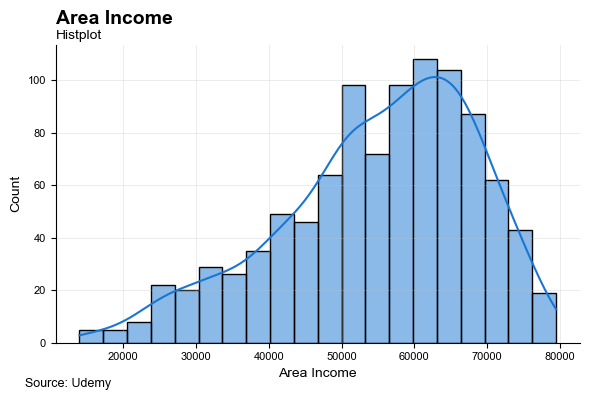

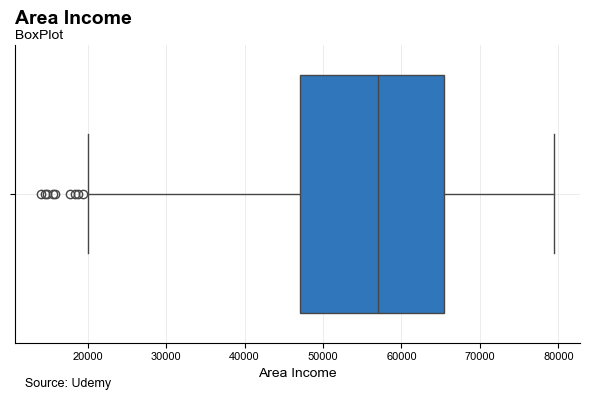

****************************************


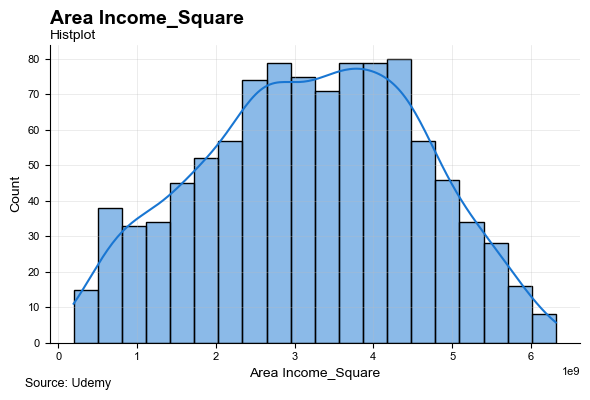

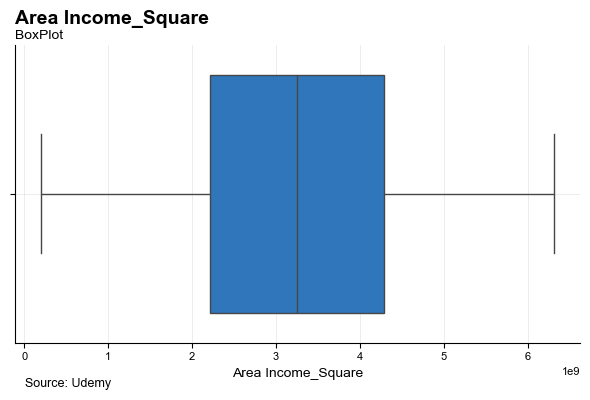

****************************************


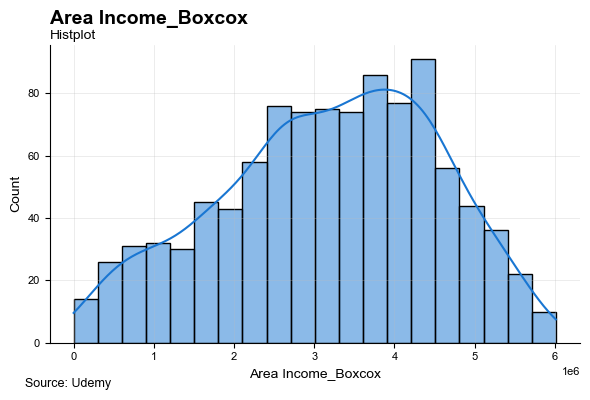

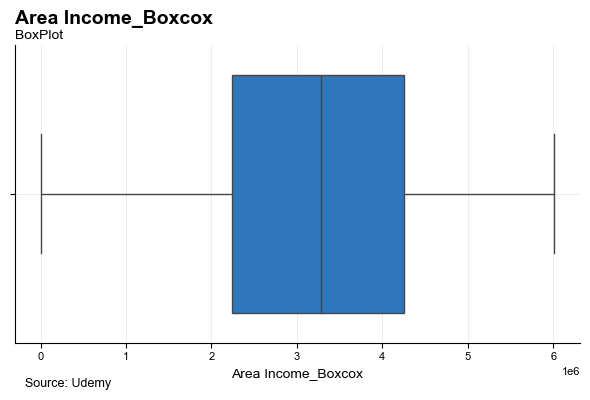

****************************************


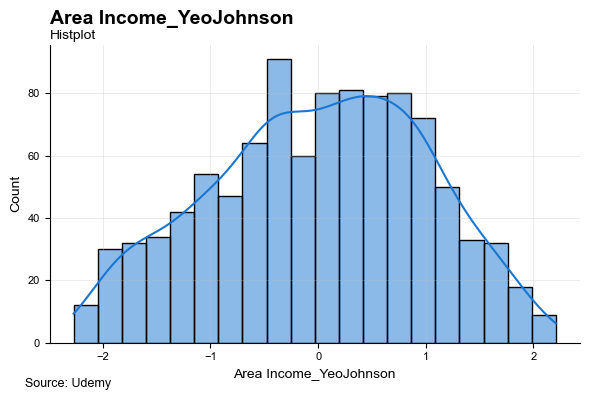

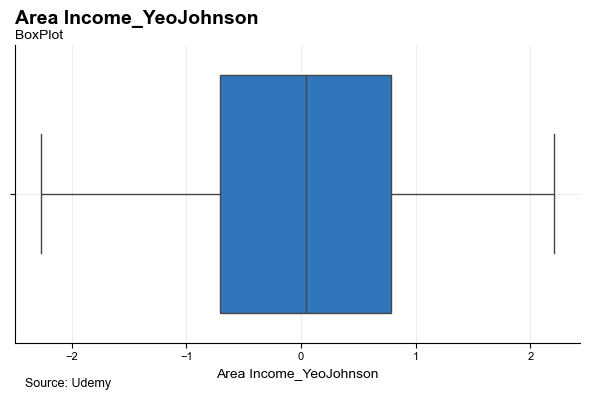

****************************************


In [12]:
# Univeriate Hisplot & Boxplot Display: Area Income
num_uni_hist_box(df,area_income_ncol)

In [13]:
# Drop Unwanted Transformation
df.drop(columns={'Area Income_Boxcox','Area Income_YeoJohnson'},inplace=True)

In [14]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [15]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [16]:
# Convert Booleans
df_processed = df_encoded.astype(int).copy()

#### C. NEURAL NETWORK: ML ENGINEERING

In [17]:
# Define Columns
selected_col = ['Area Income_Square', 'Daily Internet Usage',
       'Daily Time Spent on Site', 'Age', 'Male', 'IsWeekend',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [18]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [19]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [20]:
# Load Scaler
scaler = StandardScaler()

In [21]:
# Scale Fit Data
scaler.fit(X_train)

StandardScaler()

In [22]:
# Scale Transform Data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# Define Neural Model Function
def create_model(learning_rate=0.01, dropout_rate=0.5):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [24]:
# Train Model
best_model = create_model(learning_rate=0.01, dropout_rate=0.5)
best_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1, validation_split=0.2)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8133 - loss: 0.4236 - val_accuracy: 0.9667 - val_loss: 0.1276
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9529 - loss: 0.1226 - val_accuracy: 0.9667 - val_loss: 0.1027
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.0852 - val_accuracy: 0.9667 - val_loss: 0.1203
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9756 - loss: 0.0801 - val_accuracy: 0.9733 - val_loss: 0.1015
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9563 - loss: 0.1015 - val_accuracy: 0.9667 - val_loss: 0.1291
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9645 - loss: 0.1330 - val_accuracy: 0.9733 - val_loss: 0.1052
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9782 - loss: 0.0732 - val_accuracy: 0.9733 - val_loss: 0.1063
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9702 - loss: 0.0886 - val_accuracy: 0.9733 - val_loss:

In [25]:
# Predict
y_pred = (best_model.predict(X_test) > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [26]:
# Predict Probabililty
y_pred_prob = best_model.predict(X_test)[:, 0]

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [27]:
# Confussion Matrix
confusion_matrix_display(y_test, y_pred, labels=['Class 0', 'Class 1'])

Confusion Matrix:
----------------------------------------
                Predicted Class 0  Predicted Class 1
Actual Class 0                113                  7
Actual Class 1                  6                124


In [28]:
# Classification Report Matrix
classification_report_display(y_test, y_pred)

Classification Report:
----------------------------------------
              precision    recall  f1-score  support
0              0.949580  0.941667  0.945607  120.000
1              0.946565  0.953846  0.950192  130.000
accuracy       0.948000  0.948000  0.948000    0.948
macro avg      0.948072  0.947756  0.947899  250.000
weighted avg   0.948012  0.948000  0.947991  250.000


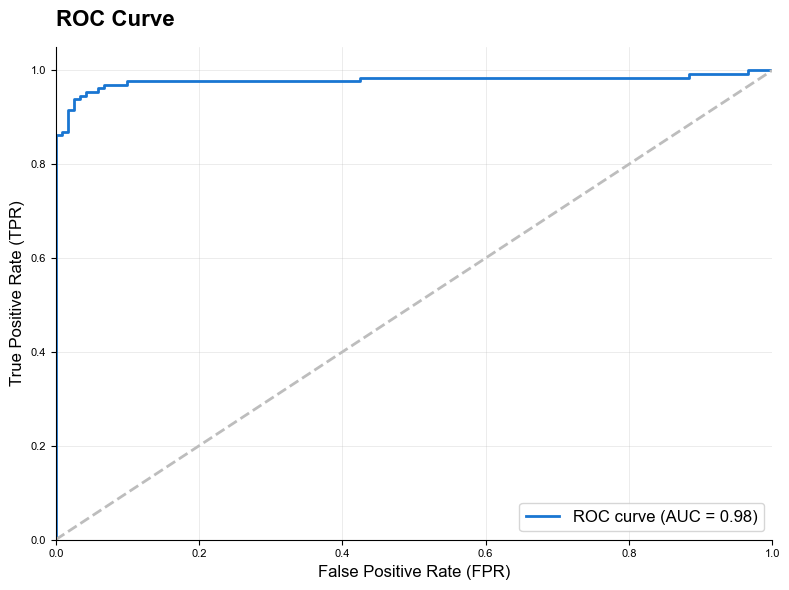

In [29]:
# ROC & AUC Curve
roc_curve_display(y_test, y_pred_prob, plot_title="ROC Curve")

In [30]:
# Define feature names correctly (excluding target column)
feature_names = ['Area Income_Square', 'Daily Internet Usage','Daily Time Spent on Site', 'Age', 'Male', 'IsWeekend']

In [31]:
# Initialize Shap
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

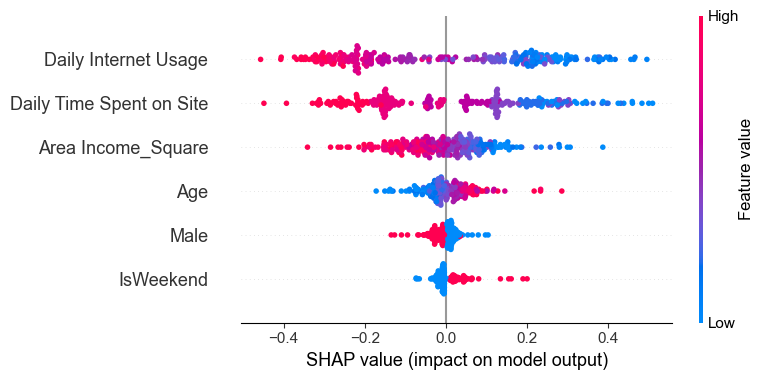

In [32]:
# Plot SHAP summary
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

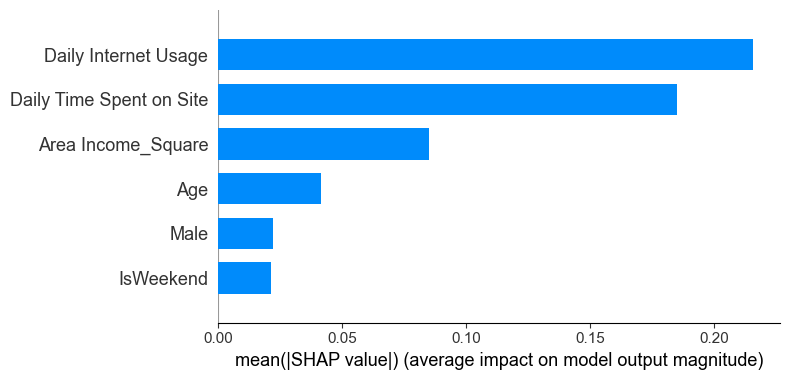

In [33]:
# Visualize SHAP Summary Plot in Bar Format (Class 1)
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), plot_type="bar")

#### D. NEURAL NETWORK: FINAL MODEL

In [34]:
# Define Columns
selected_col = ['Area Income_Square', 'Daily Internet Usage',
       'Daily Time Spent on Site', 'Age', 'Male', 'IsWeekend',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [35]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [36]:
# Load Scaler
scaler = StandardScaler()

In [37]:
# Scale Fit Data
scaler.fit(X)

StandardScaler()

In [38]:
# Scale Transform Data
X = scaler.transform(X)

In [39]:
# Final Model Load
final_model = create_model(learning_rate=0.01, dropout_rate=0.5)

In [40]:
# Final Model Fit
final_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1, validation_split=0.2)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7851 - loss: 0.4370 - val_accuracy: 0.9733 - val_loss: 0.1030
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9743 - loss: 0.1007 - val_accuracy: 0.9733 - val_loss: 0.1042
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9609 - loss: 0.1296 - val_accuracy: 0.9667 - val_loss: 0.1222
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9675 - loss: 0.1146 - val_accuracy: 0.9600 - val_loss: 0.1199
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9679 - loss: 0.1031 - val_accuracy: 0.9667 - val_loss: 0.1310
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9708 - loss: 0.0883 - val_accuracy: 0.9733 - val_loss: 0.1334
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9641 - loss: 0.1009 - val_accuracy: 0.9733 - val_loss: 0.1193
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9719 - loss: 0.0778 - val_accuracy: 0.9733 - val_loss:

In [41]:
# New Values
Area_Income_Square = np.power(24593, 2)
Daily_Internet_Usage = 1000
Daily_Time_Spent_on_Site = 1000
Age = 48
Male = 1
IsWeekedn = 1



data = {
    'Area Income_Square': [Area_Income_Square],
    'Daily Internet Usage': [Daily_Internet_Usage],
    'Daily Time Spent on Site': [Daily_Time_Spent_on_Site],
    'Age': [Age],
    'Male': [Male],
    'IsWeekend': [IsWeekedn]
}

new_pred = pd.DataFrame(data)
new_pred

,Area Income_Square,Daily Internet Usage,Daily Time Spent on Site,Age,Male,IsWeekend
0,604815649,1000,1000,48,1,1


In [42]:
# Scale New Predictions
new_pred = scaler.transform(new_pred)

In [43]:
# Predict Probabililty of Clicking
prob_class_1 = round(float(final_model.predict(new_pred)[0][0] * 100), 2)
prob_class_0 = round(100 - prob_class_1, 2)
print(f"\033[1m- Probability of Class 0:\033[0m {prob_class_0}%")
print(f"\033[1m- Probability of Class 1:\033[0m {prob_class_1}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
- Probability of Class 0: 100.0%
- Probability of Class 1: 0.0%
